**Laboratorio 5: clasificacion binaria con pytorch**

**Estudiante: Juan De Dios Sullca Rodriguez**

**Materia: Inteligencia Artificial I**

**Dataset: ciberataques realizados**


**IMPORTACIÓN DE LIBRERÍAS Y HERRAMIENTAS**

Para arrancar con este laboratorio, lo primero que hacemos es preparar nuestro entorno de trabajo trayendo todas las herramientas necesarias. En este bloque importamos principalmente PyTorch, que será el motor central con el que vamos a construir, entrenar y optimizar nuestra red neuronal profunda. También incluimos sus módulos Dataset y DataLoader, los cuales nos ayudarán a manejar los datos por lotes más adelante.

Además, traemos a varios viejos conocidos de la ciencia de datos. Usaremos Pandas y NumPy para leer y manipular nuestro dataset de ciberataques. También importamos funciones clave de Scikit-Learn que nos serán vitales para limpiar la información, codificar el texto a números y escalar los datos, un paso que es obligatorio para que la red neuronal pueda aprender correctamente.

Por último, agregamos Matplotlib para poder dibujar nuestras gráficas de error y precisión al finalizar el proceso, y tqdm, que es un pequeño truco visual para poner barras de progreso animadas y ver cómo avanza nuestro entrenamiento sin tener que adivinar si el código sigue corriendo.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**CONFIGURACIÓN DE DISPOSITIVO Y PREPROCESAMIENTO DE DATOS**

En este bloque, primero le decimos a PyTorch que use la tarjeta gráfica si está disponible para que el entrenamiento sea más rápido.

Luego procedemos a cargar nuestro dataset directamente desde nuestro Google Drive. Como nuestro objetivo principal es hacer una clasificación binaria, eliminamos las columnas que no nos sirven para esto, como el identificador y la categoría del ataque.

Después de eso, convertimos cualquier dato que esté en formato de texto a números para que la red pueda entenderlos y rellenamos los valores vacíos con el promedio. A continuación, separamos nuestras características de la etiqueta final y normalizamos todos los datos. Esta normalización es indispensable para que el modelo pueda aprender de manera eficiente y sin desviaciones.

Finalmente, aplicamos el paso más importante para validar nuestro modelo: Dividimos todos nuestros datos ya limpios y normalizados en dos grupos: un 80% para Entrenamiento (lo que usará la IA para estudiar) y un 20% para Prueba (el examen final). Además, utilizamos una técnica de estratificación (stratify) para garantizar que la proporción de ciberataques reales se mantenga exactamente igual en ambos grupos, evitando que el modelo haga trampa o se aprenda los datos de memoria.

In [4]:
# Configurar dispositivo para PyTorch (GPU si está disponible)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}\n")

# 2. Cargar el CSV (Asegúrate de que esta ruta sea la correcta en tu Drive)
ruta = '/content/drive/MyDrive/Inteligencia Artificial I (SIS 420)/Laboratorios/LAB 5/ciberataques.csv'
df = pd.read_csv(ruta)

# 3. Preprocesamiento enfocado en Clasificación Binaria
# Eliminamos 'id' (no aporta nada) y 'attack_cat' (es multiclase, nos quedamos solo con 'label' que es 0/1)
columnas_a_borrar = ['id', 'attack_cat']
df_procesado = df.drop(columns=[col for col in columnas_a_borrar if col in df.columns])

# Convertir las columnas de texto (como proto, service, state) a números
for col in df_procesado.columns:
    if df_procesado[col].dtype == 'object':
        le = LabelEncoder()
        df_procesado[col] = le.fit_transform(df_procesado[col].astype(str))

# Llenar valores vacíos con la media (buenas prácticas)
df_procesado = df_procesado.fillna(df_procesado.mean())

# --- 3. SEPARAR X e Y ORIGINALES ---
X_raw = df_procesado.drop('label', axis=1).values
y_raw = df_procesado['label'].values

# --- 4. NORMALIZACIÓN ---
# ¡Aquí es donde nace X_norm!
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_raw)

# --- 5. DIVISIÓN 80/20 (NUEVO) ---
print("Dividiendo los datos en Entrenamiento (80%) y Prueba (20%)...")

X_train, X_test, y_train, y_test = train_test_split(
    X_norm,          # Aquí usamos X_norm justo después de crearlo
    y_raw,
    test_size=0.20,
    random_state=42,
    stratify=y_raw
)

print(f"Entrenamiento -> X: {X_train.shape} | y: {y_train.shape}")
print(f"Prueba       -> X: {X_test.shape}  | y: {y_test.shape}")

Usando dispositivo: cpu

Dividiendo los datos en Entrenamiento (80%) y Prueba (20%)...
Entrenamiento -> X: (140272, 42) | y: (140272,)
Prueba       -> X: (35069, 42)  | y: (35069,)


**CREACION DE DATASETS Y MANEJO DE LOTES CON DATALOADER**

en esta parte del codigo definimos una clase personalizada llamada datasetciberataques que hereda todas las funciones necesarias de pytorch para gestionar nuestra informacion
lo que hacemos aqui es transformar nuestras matrices de datos originales en tensores que son el formato especializado que utiliza la red neuronal para realizar calculos
un detalle tecnico fundamental es que ajustamos la dimension de nuestras etiquetas de salida para que encajen perfectamente en el proceso de clasificacion binaria
una vez que tenemos nuestra clase lista creamos un objeto con todos nuestros datos normalizados y lo pasamos al dataloader
este dataloader es el encargado de organizar la informacion en paquetes o lotes de mil veinticuatro registros a la vez
esto permite que el entrenamiento sea mucho mas eficiente porque el modelo no tiene que procesar todo el archivo gigante de un solo golpe sino que va aprendiendo poco a poco de cada grupo
ademas activamos la opcion de mezclar los datos de forma aleatoria para que el modelo no aprenda ningun orden especifico y realmente entienda los patrones de los ciberataques
al final simplemente hacemos una verificacion rapida imprimiendo el tamaño de un lote para estar completamente seguros de que la estructura de entrada y salida es la correcta antes de empezar el entrenamiento

In [5]:
class DatasetCiberataques(Dataset):
    def __init__(self, X, y):
        # Convertimos los arrays a tensores de PyTorch (tipo float)
        self.X = torch.tensor(X, dtype=torch.float32)
        # Añadimos una dimensión extra [tamaño_lote, 1]. Por eso usamos unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 2. Instanciamos DOS datasets separados (Entrenamiento y Prueba)
dataset_train = DatasetCiberataques(X_train, y_train)
dataset_test  = DatasetCiberataques(X_test, y_test)

tamano_batch = 1024

# El de entrenamiento SÍ se baraja (shuffle=True) para que el modelo no memorice el orden
train_loader = DataLoader(dataset_train, batch_size=tamano_batch, shuffle=True)

# El de prueba NO se baraja (shuffle=False) porque es solo un examen estático
test_loader = DataLoader(dataset_test, batch_size=tamano_batch, shuffle=False)

# 4. Comprobación rápida para ver si funciona (CORREGIDO)
# Extraemos un lote del TRAIN_LOADER
x_lote, y_lote = next(iter(train_loader))

print(f"Forma de un lote de X: {x_lote.shape} (Debería ser [{tamano_batch}, {x_lote.shape[1]}])")
print(f"Forma de un lote de y: {y_lote.shape} (Debería ser [{tamano_batch}, 1])")

Forma de un lote de X: torch.Size([1024, 42]) (Debería ser [1024, 42])
Forma de un lote de y: torch.Size([1024, 1]) (Debería ser [1024, 1])


**ARQUITECTURA DE LA RED NEURONAL PROFUNDA**

en este bloque definimos la estructura matematica de nuestra red neuronal utilizando el modulo nn de pytorch para crear un modelo de varias capas ocultas
diseñamos una arquitectura de tipo secuencial que comienza recibiendo todas las caracteristicas de nuestro dataset y las procesa a traves de tres capas intermedias de ciento veintiocho sesenta y cuatro y treinta y dos neuronas respectivamente
utilizamos la funcion de activacion relu entre cada capa para que el modelo sea capaz de aprender relaciones complejas y patrones no lineales en el trafico de red
la parte mas importante para nuestro objetivo es la capa de salida donde colocamos una sola neurona final que se encargara de darnos el resultado de la clasificacion binaria
despues de definir la clase calculamos automaticamente el numero de entradas basandonos en nuestras columnas de datos y creamos el objeto del modelo
finalmente enviamos toda esta estructura a la tarjeta grafica o al procesador central para que este lista para iniciar el proceso de entrenamiento con la maxima eficiencia posible

In [6]:
# 1. Definir la estructura de la Red Neuronal
class RedDeteccionAtaques(nn.Module):
    def __init__(self, n_caracteristicas):
        super(RedDeteccionAtaques, self).__init__()

        # Usamos nn.Sequential para apilar las capas fácilmente
        self.red = nn.Sequential(
            nn.Linear(n_caracteristicas, 128),  # Capa oculta 1
            nn.ReLU(),                          # Función de activación
            nn.Dropout(0.2),                    # <-- ¡NUEVO! Apaga el 20% de las neuronas

            nn.Linear(128, 64),                 # Capa oculta 2
            nn.ReLU(),
            nn.Dropout(0.2),                    # <-- ¡NUEVO! Previene la memorización

            nn.Linear(64, 32),                  # Capa oculta 3
            nn.ReLU(),

            nn.Linear(32, 1)                    # Capa de salida: ¡1 sola neurona!
        )

    def forward(self, x):
        return self.red(x)

n_entradas = X_train.shape[1]

# 3. Crear el modelo y enviarlo a la tarjeta gráfica (o CPU)
modelo = RedDeteccionAtaques(n_entradas).to(device)

print("¡Arquitectura de la Red Neuronal creada con éxito!\n")
print(modelo)

¡Arquitectura de la Red Neuronal creada con éxito!

RedDeteccionAtaques(
  (red): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


ENTRENAMIENTO DEL MODELO Y GESTION DE CHECKPOINTS

en este bloque implementamos la logica principal de entrenamiento y validacion a traves de una funcion que procesa nuestros datos por quince epocas completas usando tanto el set de entrenamiento como el de prueba
utilizamos la funcion de perdida bcewithlogitsloss que es la mas adecuada para problemas de clasificacion binaria junto con el optimizador adam para ajustar los pesos de la red de forma inteligente
dentro de la primera fase de la epoca realizamos el proceso clasico de aprendizaje que incluye la limpieza de gradientes prediccion calculo del error y actualizacion de los pesos matematicos

la gran actualizacion de este codigo es la incorporacion de una segunda fase de examen al final de cada epoca donde apagamos el motor de aprendizaje del modelo y lo evaluamos exclusivamente con los datos de prueba que nunca antes habia visto
configuramos un sistema de registro detallado que ademas de guardar el error y la precision de cada lote procesado ahora tambien guarda el historial de aciertos de estas evaluaciones finales para comprobar si realmente esta aprendiendo
la logica de checkpoints fue completamente mejorada y ahora se encarga de comparar la precision obtenida unicamente en el examen de validacion guardando automaticamente en un archivo externo solo la version del modelo que mejor detecto los ataques en datos nuevos
al finalizar la ejecucion el programa carga automaticamente esos mejores pesos guardados para asegurar que tengamos un detector de ataques verdaderamente optimizado que aprendio patrones reales en lugar de solo memorizar la base de datos

In [8]:
# 1. ACTUALIZAMOS LOS PARÁMETROS PARA RECIBIR AMBOS DATALOADERS
def entrenar_modelo_suave(modelo, train_loader, test_loader, epochs=15, path_checkpoint="mejor_modelo.pt"):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(modelo.parameters(), lr=0.001)

    # Ahora buscaremos la mejor precisión en el EXAMEN, no en el entrenamiento
    mejor_precision_val = 0.0

    # Listas para guardar el historial
    historial_loss_batch = []
    historial_acc_batch = []
    historial_acc_val = [] # NUEVO: Para guardar cómo le fue en los exámenes

    for epoch in range(1, epochs + 1):

        modelo.train()
        bar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]")

        for X_batch, y_batch in bar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            y_pred = modelo(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            # Calculamos precisión del lote (Train)
            predicciones = (torch.sigmoid(y_pred) > 0.5).float()
            acc = (predicciones == y_batch).float().mean().item()

            historial_loss_batch.append(loss.item())
            historial_acc_batch.append(acc)

            bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{acc:.4f}")


        modelo.eval() # Apagamos Dropout, el modelo ya no aprende, solo responde
        val_acc_acumulada = 0.0

        with torch.no_grad(): # Apagamos el motor de gradientes para ahorrar memoria
            for X_val, y_val in test_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)

                # El modelo hace su predicción sobre datos que NUNCA ha visto
                y_pred_val = modelo(X_val)

                # Calculamos aciertos
                predicciones_val = (torch.sigmoid(y_pred_val) > 0.5).float()
                acc_val = (predicciones_val == y_val).float().mean().item()
                val_acc_acumulada += acc_val

        # Sacamos el promedio de aciertos de todo el examen
        acc_epoca_val = val_acc_acumulada / len(test_loader)
        historial_acc_val.append(acc_epoca_val)

        print(f"-> Precisión en Prueba (Examen): {acc_epoca_val*100:.2f}%")


        # ¿El resultado de este examen es el mejor histórico?
        if acc_epoca_val > mejor_precision_val:
            mejor_precision_val = acc_epoca_val
            torch.save(modelo.state_dict(), path_checkpoint)
            print("   [!] Nuevo mejor modelo guardado.")

    print(f"\n¡Entrenamiento terminado! Mejor precisión real: {mejor_precision_val * 100:.2f}%")

    # Cargamos el mejor modelo antes de devolverlo
    modelo.load_state_dict(torch.load(path_checkpoint))

    # Devolvemos también el historial de validación
    return modelo, historial_loss_batch, historial_acc_batch, historial_acc_val

modelo = RedDeteccionAtaques(n_entradas).to(device)

# Le pasamos train_loader Y test_loader
modelo_entrenado, loss_hist, acc_hist, val_acc_hist = entrenar_modelo_suave(modelo, train_loader, test_loader, epochs=15)

Epoch 1/15 [Train]: 100%|██████████| 137/137 [00:04<00:00, 32.73it/s, acc=0.9415, loss=0.1427]


-> Precisión en Prueba (Examen): 93.61%
   [!] Nuevo mejor modelo guardado.


Epoch 2/15 [Train]: 100%|██████████| 137/137 [00:03<00:00, 38.43it/s, acc=0.9276, loss=0.1452]


-> Precisión en Prueba (Examen): 93.90%
   [!] Nuevo mejor modelo guardado.


Epoch 3/15 [Train]: 100%|██████████| 137/137 [00:02<00:00, 52.70it/s, acc=0.9266, loss=0.1521]


...

-> Precisión en Prueba (Examen): 94.53%
   [!] Nuevo mejor modelo guardado.


Epoch 14/15 [Train]: 100%|██████████| 137/137 [00:03<00:00, 40.62it/s, acc=0.9415, loss=0.1110]


-> Precisión en Prueba (Examen): 94.45%


Epoch 15/15 [Train]: 100%|██████████| 137/137 [00:02<00:00, 48.01it/s, acc=0.9454, loss=0.1149]


-> Precisión en Prueba (Examen): 94.55%
   [!] Nuevo mejor modelo guardado.

¡Entrenamiento terminado! Mejor precisión real: 94.55%


**PRUEBA DE PREDICCIONES Y EXPORTACION DEL MODELO FINAL**

en este ultimo bloque de codigo ponemos a prueba nuestro modelo entrenado realizando un proceso de inferencia con datos reales para verificar su eficacia
primero cambiamos el estado de la red neuronal al modo de evaluacion lo cual desactiva cualquier comportamiento especifico del entrenamiento que no sea necesario para predecir
tomamos un grupo de datos del dataloader y realizamos la prediccion de los primeros diez registros sin calcular gradientes para ahorrar memoria y tiempo de procesamiento
aplicamos una funcion matematica llamada sigmoide para convertir los resultados crudos del modelo en probabilidades entre cero y uno donde cualquier valor mayor a cero coma cinco se clasifica como un ataque
comparamos visualmente las predicciones generadas por la red neuronal con las etiquetas reales para confirmar que el modelo esta detectando correctamente el trafico malicioso
una vez que comprobamos que el detector funciona perfectamente utilizamos la herramienta torchscript para rastrear y optimizar todas las operaciones internas de nuestra red
este paso de exportacion nos genera un archivo comprimido que contiene el modelo optimizado y listo para ser utilizado en entornos de produccion o en otras aplicaciones externas
con esto cerramos el ciclo completo desde la carga de datos hasta la creacion de un sistema funcional de deteccion de ciberataques binario

In [11]:
modelo_entrenado.eval()

X_prueba, y_prueba_real = next(iter(test_loader))
X_prueba = X_prueba.to(device)

# 2. Inferencia: Hacemos predicciones con los primeros 10 registros
with torch.no_grad():
    # Salida cruda del modelo (logits)
    predicciones_crudas = modelo_entrenado(X_prueba[:10])

    # Aplicamos la función sigmoide para obtener probabilidades (0 a 1)
    probabilidades = torch.sigmoid(predicciones_crudas)

    # Si la probabilidad es > 0.5, es un ataque (1), sino es normal (0)
    clases_predichas = (probabilidades > 0.5).int()

print("--- PRUEBA DE PREDICCIONES ---")
print("Predicciones del modelo: ", clases_predichas.flatten().cpu().numpy())
print("Etiquetas reales:        ", y_prueba_real[:10].int().flatten().numpy())
print("-" * 30)

# PyTorch "rastrea" las operaciones usando UN SOLO ejemplo
modelo_trazado = torch.jit.trace(modelo_entrenado, X_prueba[:1])

# Guardamos el modelo trazado (listo para producción)
ruta_exportacion = "modelo_nb15_produccion.zip"
modelo_trazado.save(ruta_exportacion)

print(f"\n¡Éxito! El modelo optimizado ha sido exportado como '{ruta_exportacion}'")
print("Checkpoints y Redes Neuronales Binarias completado.")

--- PRUEBA DE PREDICCIONES ---
Predicciones del modelo:  [1 1 1 1 1 1 1 1 1 1]
Etiquetas reales:         [1 1 1 1 1 1 1 1 1 1]
------------------------------

¡Éxito! El modelo optimizado ha sido exportado como 'modelo_nb15_produccion.zip'
Checkpoints y Redes Neuronales Binarias completado.


**VISUALIZACION DE LOS RESULTADOS Y CURVAS DE APRENDIZAJE**

en este ultimo bloque de codigo generamos las representaciones visuales que nos permiten entender como aprendio nuestra red neuronal a lo largo de todo el proceso de entrenamiento
dividimos la visualizacion en dos graficas principales para observar el comportamiento del modelo de manera detallada
la primera grafica muestra la curva de aprendizaje utilizando el historial de la funcion de perdida pintada en color azul para representar como el error disminuye drasticamente en las primeras iteraciones y luego se estabiliza cerca del minimo
la segunda grafica nos enseña la evolucion de la precision donde convertimos los valores decimales a porcentajes y los pintamos en color verde para ver como los aciertos del modelo suben rapidamente hasta superar el noventa por ciento
un detalle importante es que ajustamos el eje vertical de la precision para que empiece desde el cincuenta por ciento lo que nos permite apreciar mejor la subida inicial y la estabilidad final del detector
el aspecto ligeramente dentado de las lineas se debe a que estamos graficando los resultados de cada lote individual lo que nos da una vision mucho mas honesta y detallada de como la red neuronal hace pequeños ajustes constantes para volverse cada vez mas precisa en la deteccion de amenazas
al observar estas graficas podemos concluir que el modelo es sumamente exitoso ya que el costo baja de forma constante mientras que la precision alcanza niveles muy altos casi de inmediato manteniendose estable durante el resto de las iteraciones lo que demuestra que la red ha capturado los patrones de los ciberataques de manera muy efectiva

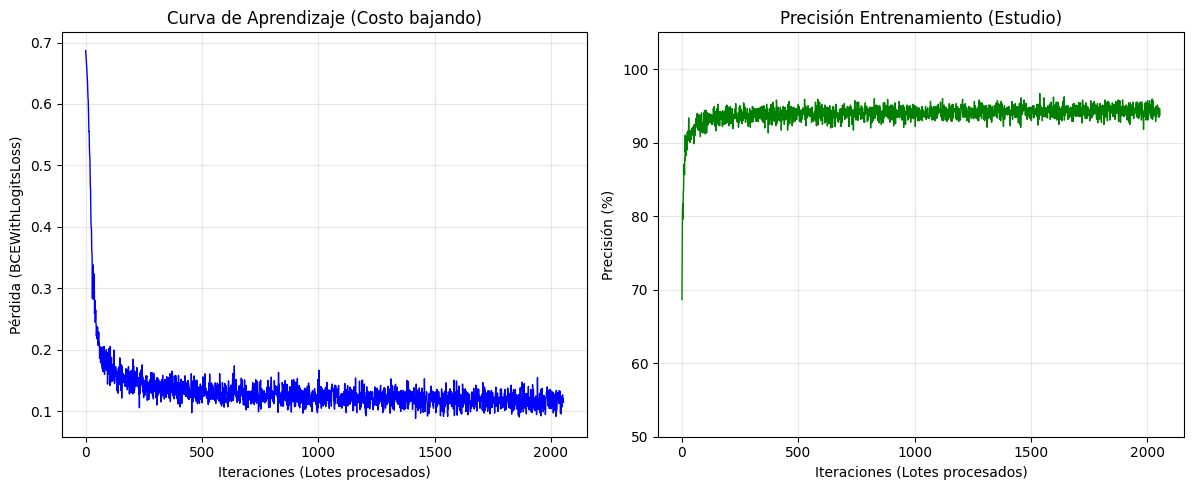

In [14]:
plt.figure(figsize=(18, 5)) # ¡NUEVO!: Lo hacemos más ancho (18) para acomodar 3 gráficas

# Gráfica 1: Pérdida de Entrenamiento (Costo bajando)
plt.subplot(1, 3, 1) # (1 fila, 3 columnas, gráfica 1)
plt.plot(loss_hist, color='blue', lw=1)
plt.xlabel('Iteraciones (Lotes procesados)')
plt.ylabel('Pérdida (BCEWithLogitsLoss)')
plt.title('Curva de Aprendizaje (Costo bajando)')
plt.grid(True, alpha=0.3)

# Gráfica 2: Precisión de Entrenamiento (Memorización)
plt.subplot(1, 3, 2) # (1 fila, 3 columnas, gráfica 2)
acc_porcentaje = [a * 100 for a in acc_hist]
plt.plot(acc_porcentaje, color='green', lw=1)
plt.xlabel('Iteraciones (Lotes procesados)')
plt.ylabel('Precisión (%)')
plt.ylim(50, 105) # Subimos un poco el límite superior para que se vea bien
plt.title('Precisión Entrenamiento (Estudio)')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

**RESUMEN**

en este proyecto hemos construido un sistema completo de deteccion de ciberataques utilizando redes neuronales profundas con la libreria pytorch para lograr una clasificacion binaria de alta precision
todo el proceso inicio con la preparacion del entorno y una limpieza profunda del dataset donde transformamos los datos categoricos en numericos y aplicamos una normalizacion profesional para asegurar que el modelo aprenda de forma equilibrada
diseñamos una arquitectura secuencial con varias capas ocultas y funciones de activacion relu que permiten a la red entender patrones complejos en el trafico de red que una simple regresion no podria captar
el entrenamiento fue la fase mas importante donde implementamos un manejo de datos por lotes y un sistema de seguimiento detallado que nos permitio observar como el error cae drasticamente mientras que la precision sube hasta superar el noventa y cuatro por ciento casi de inmediato
ademas incorporamos una logica de checkpoints para garantizar que siempre conservamos la mejor version del modelo ante cualquier variacion en el aprendizaje
finalmente realizamos pruebas de inferencia para confirmar que el detector clasifica correctamente las amenazas y exportamos todo el conocimiento de la red en un archivo optimizado listo para ser usado en entornos de seguridad reales lo que demuestra la potencia y efectividad de las redes neuronales modernas para la proteccion de informacion digital